In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
os.makedirs('/content/TER/data', exist_ok=True)
shutil.copy('/content/drive/MyDrive/Colab Notebooks/ChatGPT_final.csv',
            '/content/TER/data/ChatGPT_final.csv')

import pandas as pd
df = pd.read_csv('/content/TER/data/ChatGPT_final.csv',
                 usecols=['Tweet', 'sentiment', 'compound_score'],
                 low_memory=False)

df = df.dropna(subset=['Tweet', 'sentiment'])

# Échantillon stratifié de 150 tweets
sample = df.groupby('sentiment', group_keys=False).apply(
    lambda x: x.sample(50, random_state=42)
).reset_index(drop=True)[['Tweet', 'sentiment', 'compound_score']]

sample = sample.sample(frac=1, random_state=42).reset_index(drop=True)
sample['manual_label'] = ''

# Sauvegarder pour annotation
sample.to_csv('/content/TER/data/annotation_sample.csv', index=False)
print(f"Sample saved: {len(sample)} tweets")
print(sample['sentiment'].value_counts())

Mounted at /content/drive
Sample saved: 150 tweets
sentiment
neutral     50
negative    50
positive    50
Name: count, dtype: int64


/tmp/ipykernel_664/3247892377.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = df.groupby('sentiment', group_keys=False).apply(


In [2]:
from google.colab import files
files.download('/content/TER/data/annotation_sample.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
from google.colab import files
uploaded = files.upload()  # Sélectionne annotation_filled.csv

Saving annotation_filled.csv to annotation_filled.csv


In [5]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns

# Charger le fichier annoté
df_annot = pd.read_csv('annotation_filled.csv')

# Nettoyer
df_annot['sentiment'] = df_annot['sentiment'].str.strip().str.lower()
df_annot['manual_label'] = df_annot['manual_label'].str.strip().str.lower()
df_annot = df_annot.dropna(subset=['manual_label'])
df_annot = df_annot[df_annot['manual_label'] != '']

print(f"Tweets annotés: {len(df_annot)}")
print(f"\nDistribution VADER:\n{df_annot['sentiment'].value_counts()}")
print(f"\nDistribution manuelle:\n{df_annot['manual_label'].value_counts()}")

# Accord global
accord = (df_annot['sentiment'] == df_annot['manual_label']).mean()
print(f"\nAccord VADER vs Manuel: {accord*100:.1f}%")

# Cohen's Kappa
kappa = cohen_kappa_score(df_annot['sentiment'], df_annot['manual_label'])
print(f"Cohen's Kappa: {kappa:.3f}")

# Classification report
print("\n=== Classification Report (VADER vs Manuel) ===")
print(classification_report(df_annot['manual_label'], df_annot['sentiment'],
      target_names=['negative', 'neutral', 'positive']))

Tweets annotés: 150

Distribution VADER:
sentiment
neutral     50
negative    50
positive    50
Name: count, dtype: int64

Distribution manuelle:
manual_label
neutral     113
negative     20
positive     17
Name: count, dtype: int64

Accord VADER vs Manuel: 45.3%
Cohen's Kappa: 0.180

=== Classification Report (VADER vs Manuel) ===
              precision    recall  f1-score   support

    negative       0.26      0.65      0.37        20
     neutral       0.86      0.38      0.53       113
    positive       0.24      0.71      0.36        17

    accuracy                           0.45       150
   macro avg       0.45      0.58      0.42       150
weighted avg       0.71      0.45      0.49       150



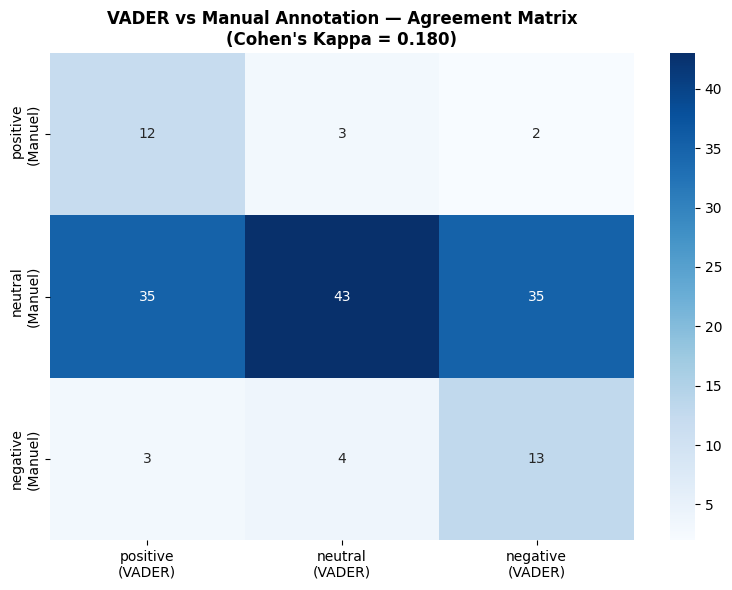


=== VADER dit POSITIVE, toi NEUTRAL ===
  [0.66] #ChatGPT just changed my resume and cover letter to something I like much better than what I have be...
  [0.83] @blewistexas @ericcurts @OpenAI Thanks for sharing! It will be interesting to see #ChatGPT functions...
  [0.53] Wisdom of the crowd training #ChatGPT...

=== VADER dit NEGATIVE, toi NEUTRAL ===
  [-0.30] @Thapz__ No need for that. We've got #ChatGPT now....
  [-0.63] chatGPT Is TERRIBLE For Email Marketing! #shorts #chatgpt - By @neilpatel [ #DigitalMarketing #Marke...
  [-0.23] Ugh, why do people think using #ChatGPT to create content is ok? It's just lazy and unoriginal.

Cre...


In [8]:
# Matrice de confusion
cm = confusion_matrix(df_annot['manual_label'], df_annot['sentiment'],
                      labels=['positive', 'neutral', 'negative'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['positive\n(VADER)', 'neutral\n(VADER)', 'negative\n(VADER)'],
            yticklabels=['positive\n(Manuel)', 'neutral\n(Manuel)', 'negative\n(Manuel)'])
plt.title('VADER vs Manual Annotation — Agreement Matrix\n(Cohen\'s Kappa = 0.180)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/TER/figures/16_vader_vs_manual.png', dpi=150)
plt.show()

# Exemples de désaccords
print("\n=== VADER dit POSITIVE, toi NEUTRAL ===")
disagree = df_annot[(df_annot['sentiment']=='positive') & (df_annot['manual_label']=='neutral')]
for _, row in disagree.head(3).iterrows():
    print(f"  [{row['compound_score']:.2f}] {row['Tweet'][:100]}...")

print("\n=== VADER dit NEGATIVE, toi NEUTRAL ===")
disagree2 = df_annot[(df_annot['sentiment']=='negative') & (df_annot['manual_label']=='neutral')]
for _, row in disagree2.head(3).iterrows():
    print(f"  [{row['compound_score']:.2f}] {row['Tweet'][:100]}...")

In [7]:
import os
os.makedirs('/content/TER/figures', exist_ok=True)
plt.savefig('/content/TER/figures/16_vader_vs_manual.png', dpi=150)
print("Saved ✓")

Saved ✓


<Figure size 640x480 with 0 Axes>

In [11]:
import subprocess, shutil, os, re
from getpass import getpass

!git clone https://github.com/falkodz/TER.git /content/TER_new 2>/dev/null || true

os.makedirs('/content/TER/notebooks', exist_ok=True)

shutil.copy('/content/drive/MyDrive/Colab Notebooks/11_manual_annotation.ipynb',
            '/content/TER/notebooks/11_manual_annotation.ipynb')

subprocess.run(['git', 'config', 'user.email', 'ton@email.com'], cwd='/content/TER')
subprocess.run(['git', 'config', 'user.name', 'falkodz'], cwd='/content/TER')
subprocess.run(['git', 'add', '.'], cwd='/content/TER')
r = subprocess.run(['git', 'commit', '-m', 'Add manual annotation + VADER validation (Kappa=0.18)'],
                   cwd='/content/TER', capture_output=True, text=True)
print(r.stdout, r.stderr)

token = getpass("Token : ")
result = subprocess.run(
    ['git', 'push', f'https://{token}@github.com/falkodz/TER.git', 'main'],
    cwd='/content/TER', capture_output=True, text=True
)
print(result.stdout, result.stderr)

[main 9bfc044] Add manual annotation + VADER validation (Kappa=0.18)
 1 file changed, 1 insertion(+)
 create mode 100644 notebooks/11_manual_annotation.ipynb
 
Token : ··········
 To https://github.com/falkodz/TER.git
   146e3dc..9bfc044  main -> main



In [12]:
import os
!rm -rf /content/TER
!git clone https://github.com/falkodz/TER.git /content/TER
os.makedirs('/content/TER/notebooks', exist_ok=True)
os.makedirs('/content/TER/figures', exist_ok=True)
print("Done ✓")

Cloning into '/content/TER'...
remote: Enumerating objects: 92, done.
remote: Counting objects: 100% (92/92), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 92 (delta 43), reused 66 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (92/92), 4.70 MiB | 18.74 MiB/s, done.
Resolving deltas: 100% (43/43), done.
Done ✓


In [13]:
import shutil, os

# Copier toutes les figures générées dans cette session
figures_to_copy = {
    '/content/TER/figures/15_error_analysis.png': '/content/TER/figures/15_error_analysis.png',
    '/content/TER/figures/16_vader_vs_manual.png': '/content/TER/figures/16_vader_vs_manual.png',
}

# En réalité elles sont déjà dans /content/TER/figures/ si le dossier vient du clone
# Vérifions ce qui est là
print("Figures actuelles dans le repo:")
for f in os.listdir('/content/TER/figures'):
    print(f"  {f}")

Figures actuelles dans le repo:
  08_weekly_wordclouds.png
  11_walkforward_evaluation.png
  03_sentiment_distribution.png
  13_lda_topic_evolution.png
  06_sentiment_timeseries.png
  12_lda_topics.png
  01_daily_volume.png
  02_wordcloud_raw.png
  07_changepoints_events.png
  05_confusion_matrix.png
